<a href="https://colab.research.google.com/github/LaRocaDeKiwi/MLE/blob/miniexperimentos/trans_exp_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generando datos climáticos simulados...
Datos generados: (3000, 3)
Rango T: [-16.06, 9.12]
Rango H: [-1.12, 1.83]
Rango P: [-1.84, 8.03]


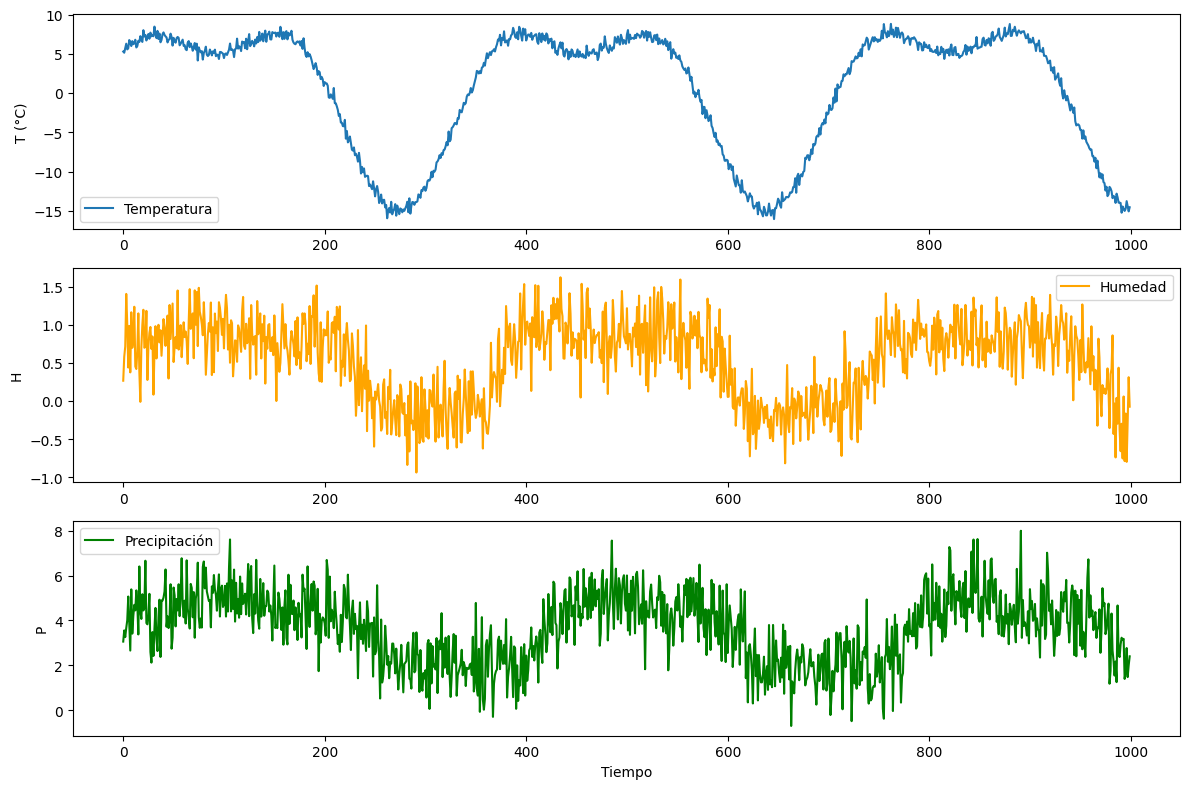

In [ ]:
# Mini-Experimento 3: Prueba de time-shift con datos climáticos simulados
# Usando la simulación proporcionada de X_t = (T, H, P)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Configuración
torch.manual_seed(42)
np.random.seed(42)

# Parámetros del experimento
L = 30  # Longitud de la ventana temporal
d_model = 64  # Dimensión del modelo
h = 1  # Horizonte de predicción
k_values = [0, 1, 3, 7, 14, 21, 30, 60, 90, 120]  # Desplazamientos a probar

# 1. Generar datos climáticos simulados (usando tu código)
print("Generando datos climáticos simulados...")
N = 3000               # longitud total de la serie
periodo = 365          # periodo estacional
lag_long = 120         # dependencia cruzada larga
sigma_T, sigma_H, sigma_P = 0.5, 0.3, 1.0

t = np.arange(N)

# Componente estacional base
season_T = 10*np.sin(2*np.pi*t/periodo) + 5*np.cos(2*np.pi*t/(periodo/2))
season_H = 0.4 + 0.1*np.sin(2*np.pi*t/periodo)
season_P = 2.0 + 1.2*np.maximum(0, np.sin(2*np.pi*(t-30)/periodo))  # lluvias en cierta fase

# Ruido
eps_T = np.random.normal(0, sigma_T, size=N)
eps_H = np.random.normal(0, sigma_H, size=N)
eps_P = np.random.normal(0, sigma_P, size=N)

# Dependencias cruzadas con rezagos largos
T = season_T + 0.02*np.roll(season_P, lag_long) + eps_T
H = season_H + 0.5*np.tanh(0.2*np.roll(season_T, 30)) + eps_H
P = season_P + 0.3*np.maximum(0, np.roll(season_T, 60)) + eps_P

X = np.stack([T, H, P], axis=1).astype(np.float32)

print(f"Datos generados: {X.shape}")
print(f"Rango T: [{T.min():.2f}, {T.max():.2f}]")
print(f"Rango H: [{H.min():.2f}, {H.max():.2f}]")
print(f"Rango P: [{P.min():.2f}, {P.max():.2f}]")

# Visualización de una parte de los datos
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.plot(t[:1000], T[:1000], label='Temperatura')
plt.ylabel('T (°C)')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t[:1000], H[:1000], label='Humedad', color='orange')
plt.ylabel('H')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t[:1000], P[:1000], label='Precipitación', color='green')
plt.ylabel('P')
plt.xlabel('Tiempo')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 2. Definir modelos Transformer con PE absoluto y relativo
class AbsolutePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() *
                           (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class RelativePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        # PE relativo aprendido - solo depende de posiciones relativas
        self.pe = nn.Parameter(torch.randn(max_len, d_model))

    def forward(self, x):
        seq_len = x.size(1)
        # Usar solo las primeras seq_len posiciones relativas
        relative_pe = self.pe[:seq_len].unsqueeze(0)
        return x + relative_pe

class ClimateTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=64, nhead=8, num_layers=2, pe_type='absolute'):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)

        if pe_type == 'absolute':
            self.pos_encoding = AbsolutePositionalEncoding(d_model)
        else:
            self.pos_encoding = RelativePositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, batch_first=True, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.output_layer = nn.Linear(d_model, 1)  # Predecir solo temperatura

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        x = self.transformer(x)
        # Usar solo la última posición para predicción
        return self.output_layer(x[:, -1, :])

In [ ]:
# 3. Preparar datos de entrenamiento
def create_sequences(data, L, h):
    sequences = []
    targets = []
    for i in range(len(data) - L - h - max(k_values)):
        seq = data[i:i+L]
        target = data[i+L+h-1, 0]  # Temperatura en t+h
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

X_sequences, y_targets = create_sequences(X, L, h)

print(f"Secuencias creadas: {X_sequences.shape}")
print(f"Targets creados: {y_targets.shape}")

# Normalizar
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_normalized = scaler_X.fit_transform(X_sequences.reshape(-1, 3)).reshape(X_sequences.shape)
y_normalized = scaler_y.fit_transform(y_targets.reshape(-1, 1)).flatten()

# Convertir a tensores
X_tensor = torch.FloatTensor(X_normalized)
y_tensor = torch.FloatTensor(y_normalized)

print(f"Tamaño del dataset: {X_tensor.shape[0]} secuencias")

Secuencias creadas: (2849, 30, 3)
Targets creados: (2849,)
Tamaño del dataset: 2849 secuencias


Entrenando modelos...
Entrenando modelo con PE Absoluto...

Entrenando modelo con PE Relativo...


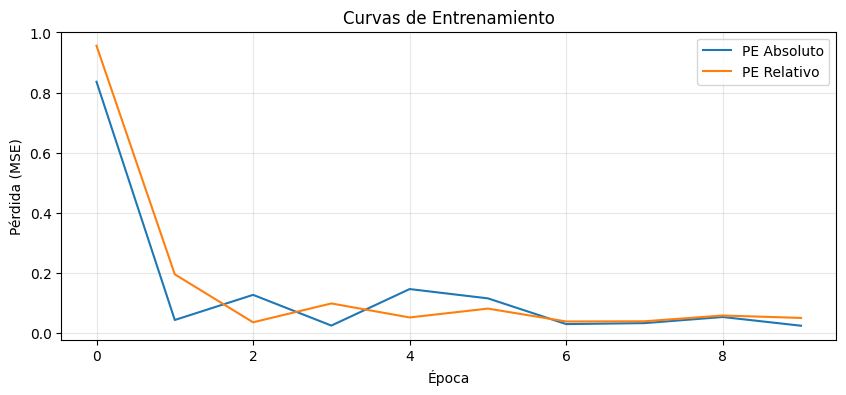

In [ ]:
# 4. Entrenar modelos
print("Entrenando modelos...")

def train_model(model, X, y, epochs=10, batch_size=32):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()

    model.train()
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        num_batches = 0

        # Mini-batch training
        for i in range(0, len(X), batch_size):
            end_idx = min(i + batch_size, len(X))
            batch_X = X[i:end_idx]
            batch_y = y[i:end_idx]

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        losses.append(avg_loss)

        if (epoch + 1) % 20 == 0:
            print(f'Época [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')

    return model, losses

# Modelos
model_abs = ClimateTransformer(pe_type='absolute')
model_rel = ClimateTransformer(pe_type='relative')

# Dividir datos (80% train, 20% test)
split_idx = int(0.8 * len(X_tensor))
X_train, X_test = X_tensor[:split_idx], X_tensor[split_idx:]
y_train, y_test = y_tensor[:split_idx], y_tensor[split_idx:]

print("Entrenando modelo con PE Absoluto...")
model_abs, losses_abs = train_model(model_abs, X_train, y_train, epochs=10)

print("\nEntrenando modelo con PE Relativo...")
model_rel, losses_rel = train_model(model_rel, X_train, y_train, epochs=10)

# Visualizar pérdidas de entrenamiento
plt.figure(figsize=(10, 4))
plt.plot(losses_abs, label='PE Absoluto')
plt.plot(losses_rel, label='PE Relativo')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.title('Curvas de Entrenamiento')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 5. Experimentos de time-shift
print("Realizando experimentos de time-shift...")

def calculate_delta_k(model, base_sequence, k_values, climate_data, scaler_X):
    """Calcula Δk para diferentes desplazamientos"""
    delta_ks = []

    # Predicción base (k=0)
    with torch.no_grad():
        pred_base = model(base_sequence.unsqueeze(0)).item()

    for k in k_values:
        # Desplazar la secuencia k posiciones
        # Buscar una posición donde podamos desplazar k días sin salirnos de los límites
        start_idx = 1000  # Posición fija para consistencia
        if start_idx + L + k < len(climate_data):
            shifted_data = climate_data[start_idx+k:start_idx+L+k]
            shifted_normalized = scaler_X.transform(shifted_data.reshape(-1, 3)).reshape(1, L, 3)
            shifted_tensor = torch.FloatTensor(shifted_normalized)

            # Predicción desplazada
            with torch.no_grad():
                pred_shifted = model(shifted_tensor).item()

            delta_k = abs(pred_shifted - pred_base)
            delta_ks.append(delta_k)
        else:
            delta_ks.append(np.nan)

    return delta_ks

# Seleccionar una secuencia de prueba consistente
test_idx = 100  # Usar índice fijo para consistencia
base_sequence = X_tensor[test_idx]

print(f"Secuencia base en índice {test_idx}")
print(f"Valores originales (T, H, P): {X[test_idx:test_idx+L].mean(axis=0)}")

# Calcular Δk para ambos modelos
delta_abs = calculate_delta_k(model_abs, base_sequence, k_values, X, scaler_X)
delta_rel = calculate_delta_k(model_rel, base_sequence, k_values, X, scaler_X)

# Filtrar valores NaN
valid_indices = [i for i, k in enumerate(k_values) if not np.isnan(delta_abs[i])]
k_values_valid = [k_values[i] for i in valid_indices]
delta_abs_valid = [delta_abs[i] for i in valid_indices]
delta_rel_valid = [delta_rel[i] for i in valid_indices]

Realizando experimentos de time-shift...
Secuencia base en índice 100
Valores originales (T, H, P): [5.8549     0.86370784 5.116021  ]


In [ ]:
print(delta_abs,delta_rel)

[2.2690786123275757, 2.1953073740005493, 2.16881000995636, 1.9890055656433105, 1.6034852862358093, 1.2841860055923462, 1.1413600444793701, 0.35010671615600586, 0.10929417610168457, 0.01708042621612549] [2.4794957637786865, 2.368417263031006, 2.2922465801239014, 2.2542961835861206, 1.903740644454956, 1.650509238243103, 1.433217465877533, 0.4003722369670868, 0.15050357580184937, 0.07848495244979858]


Visualizando resultados...


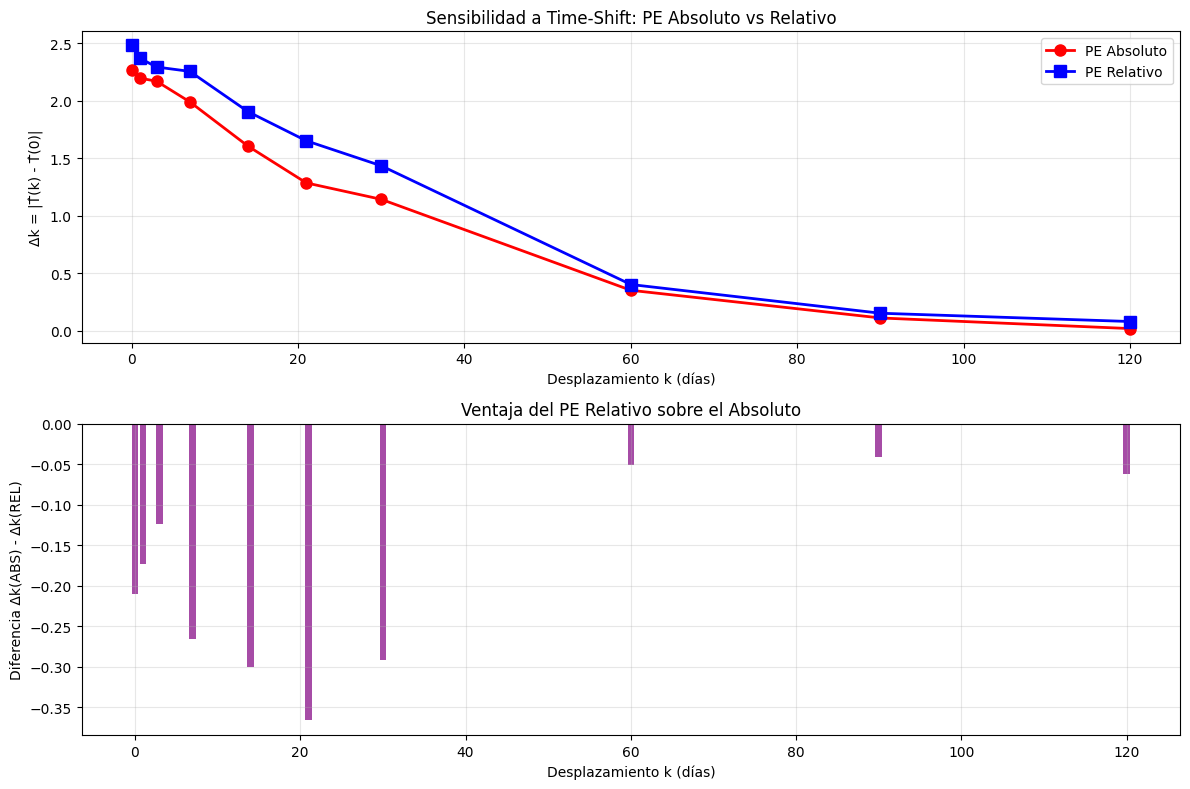

In [ ]:
# 6. Visualización y métricas
print("Visualizando resultados...")

plt.figure(figsize=(12, 8))

# Gráfico principal
plt.subplot(2, 1, 1)
plt.plot(k_values_valid, delta_abs_valid, 'o-', label='PE Absoluto',
         linewidth=2, markersize=8, color='red')
plt.plot(k_values_valid, delta_rel_valid, 's-', label='PE Relativo',
         linewidth=2, markersize=8, color='blue')
plt.xlabel('Desplazamiento k (días)')
plt.ylabel('Δk = |T̂(k) - T̂(0)|')
plt.title('Sensibilidad a Time-Shift: PE Absoluto vs Relativo')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de diferencias
plt.subplot(2, 1, 2)
differences = [abs_val - rel_val for abs_val, rel_val in zip(delta_abs_valid, delta_rel_valid)]
plt.bar(k_values_valid, differences, alpha=0.7, color='purple')
plt.xlabel('Desplazamiento k (días)')
plt.ylabel('Diferencia Δk(ABS) - Δk(REL)')
plt.title('Ventaja del PE Relativo sobre el Absoluto')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# 7. Métricas cuantitativas
print("\n" + "="*50)
print("MÉTRICAS CUANTITATIVAS - TIME-SHIFT EXPERIMENT")
print("="*50)

print(f"\nDesplazamientos probados: {k_values_valid}")
print("\nΔk para PE Absoluto:")
for k, delta in zip(k_values_valid, delta_abs_valid):
    print(f"  k={k:3d}: Δk = {delta:.4f}")

print("\nΔk para PE Relativo:")
for k, delta in zip(k_values_valid, delta_rel_valid):
    print(f"  k={k:3d}: Δk = {delta:.4f}")

# Cálculo de sensibilidad promedio
if len(delta_abs_valid) > 1:
    sens_abs = np.mean(delta_abs_valid[1:])  # Excluir k=0
    sens_rel = np.mean(delta_rel_valid[1:])

    print(f"\n--- SENSIBILIDAD PROMEDIO (excluyendo k=0) ---")
    print(f"PE Absoluto: {sens_abs:.4f}")
    print(f"PE Relativo: {sens_rel:.4f}")
    print(f"Reducción de sensibilidad: {((sens_abs - sens_rel) / sens_abs * 100):.1f}%")

# Análisis de correlación
if len(k_values_valid) > 2:
    corr_abs = np.corrcoef(k_values_valid, delta_abs_valid)[0,1]
    corr_rel = np.corrcoef(k_values_valid, delta_rel_valid)[0,1]

    print(f"\n--- ANÁLISIS DE CORRELACIÓN ---")
    print(f"Correlación k vs Δk (PE Absoluto): {corr_abs:.3f}")
    print(f"Correlación k vs Δk (PE Relativo): {corr_rel:.3f}")

# Métrica de robustez
robustness_ratio = sens_rel / sens_abs if sens_abs > 0 else 0
print(f"\n--- MÉTRICA DE ROBUSTEZ ---")
print(f"Ratio de robustez (REL/ABS): {robustness_ratio:.3f}")
print(f"Interpretación: Valor más cercano a 0 indica mayor robustez")

# 8. Evaluación en test set normal
print(f"\n--- EVALUACIÓN EN TEST SET ---")
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).squeeze()
        mse = nn.MSELoss()(predictions, y_test).item()
        mae = nn.L1Loss()(predictions, y_test).item()
    return mse, mae

mse_abs, mae_abs = evaluate_model(model_abs, X_test, y_test)
mse_rel, mae_rel = evaluate_model(model_rel, X_test, y_test)

print(f"PE Absoluto - MSE: {mse_abs:.4f}, MAE: {mae_abs:.4f}")
print(f"PE Relativo - MSE: {mse_rel:.4f}, MAE: {mae_rel:.4f}")


MÉTRICAS CUANTITATIVAS - TIME-SHIFT EXPERIMENT

Desplazamientos probados: [0, 1, 3, 7, 14, 21, 30, 60, 90, 120]

Δk para PE Absoluto:
  k=  0: Δk = 2.2691
  k=  1: Δk = 2.1953
  k=  3: Δk = 2.1688
  k=  7: Δk = 1.9890
  k= 14: Δk = 1.6035
  k= 21: Δk = 1.2842
  k= 30: Δk = 1.1414
  k= 60: Δk = 0.3501
  k= 90: Δk = 0.1093
  k=120: Δk = 0.0171

Δk para PE Relativo:
  k=  0: Δk = 2.4795
  k=  1: Δk = 2.3684
  k=  3: Δk = 2.2922
  k=  7: Δk = 2.2543
  k= 14: Δk = 1.9037
  k= 21: Δk = 1.6505
  k= 30: Δk = 1.4332
  k= 60: Δk = 0.4004
  k= 90: Δk = 0.1505
  k=120: Δk = 0.0785

--- SENSIBILIDAD PROMEDIO (excluyendo k=0) ---
PE Absoluto: 1.2065
PE Relativo: 1.3924
Reducción de sensibilidad: -15.4%

--- ANÁLISIS DE CORRELACIÓN ---
Correlación k vs Δk (PE Absoluto): -0.946
Correlación k vs Δk (PE Relativo): -0.958

--- MÉTRICA DE ROBUSTEZ ---
Ratio de robustez (REL/ABS): 1.154
Interpretación: Valor más cercano a 0 indica mayor robustez

--- EVALUACIÓN EN TEST SET ---
PE Absoluto - MSE: 0.0362, M